# Spin-Bath Inference — Adaptive Experiment Workflow
---
**Purpose**  
Infer the nuclear spin-bath composition of an NV center from coherence measurements,
and automatically recommend the *most informative* next experiment.

**What this notebook does**
1. Loads the ab-initio hyperfine spin library.
2. Runs Reversible-Jump MCMC (RJMCMC) to infer the posterior distribution over spin-bath configurations.
3. Displays the posterior and summary statistics.
4. Ranks candidate experiments by Expected Information Gain (EIG) and recommends the best next measurement.
5. Repeats when new data become available.

**Typical workflow**
```
[You]                            [Notebook]
Upload/record experiment data  →  run_inference()
                               →  plot_posterior()
                               →  suggest_next_experiment()
                               ←  Recommended time-points & pulse count
Do experiment                  →  (repeat)
```

**Required inputs**
- Ab-initio hyperfine file (`hf_file` path, set in USER SETTINGS)
- Coherence data arrays for each completed experiment

> *You only need to edit the USER SETTINGS section below.  Everything else runs automatically.*

## 0 · Imports

In [1]:
# Standard library & scientific stack
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl

# ── Pipeline helpers (wraps RJMCMC / adaptive-exp backends unchanged) ────────
from workflow_pipeline import (
    default_config,
    load_hyperfine_data,
    load_or_compute_hyperfine_data,
    build_initial_experiment,
    simulate_coherence_data,
    load_coherence_data_from_arrays,
    run_inference,
    plot_posterior,
    plot_convergence,
    plot_posterior_fits,
    build_candidate_experiments,
    suggest_next_experiment,
    display_recommendation,
    plot_information_diagnostic,
    print_posterior_summary,
    save_state,
    load_state,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Imports OK ✓")


Imports OK ✓


/Users/abbypoteshman/Library/Python/3.9/lib/python/site-packages/pycce/bath/array.py:1917: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  all_spins = pd.read_csv(filepath, delim_whitespace=True, header=None, comment='%',


## 1 · User Settings
Edit **only this cell** to configure the full pipeline.  
All other cells should run without modification.

In [24]:
# =============================================================================
#  USER SETTINGS  –  edit the values below as needed
# =============================================================================

config = default_config()   # start from sensible defaults, then override:

# ── Hyperfine spin library ────────────────────────────────────────────────────
config["hf_file"]       = "nv-2.txt"   # path to your ab-initio HF file
config["strong_thresh"] = 750.0        # kHz  – remove spins stronger than this
config["weak_thresh"]   = 5.0         # kHz  – remove spins weaker than this

# ── First experiment ──────────────────────────────────────────────────────────
config["init_num_pulses"] = 4          # number of DD pulses
config["init_mag_field"]  = 332.0     # magnetic field (Gauss)
config["init_noise"]      = 0.008     # measurement noise σ
config["init_T2"]         = 0.9       # initial T2 (ms)
config["init_tmin"]       = 0.0       # start time (ms)
config["init_tmax"]       = 0.008     # end time (ms)
config["init_num_tps"]    = 50        # number of time points measured

# ── RJMCMC sampler ────────────────────────────────────────────────────────────
config["k_max"]              = 20     # max spins in bath
config["num_trials"]         = 10_000 # total MCMC steps (increase for harder problems)
config["burn_in"]            = 5_000  # steps to discard as warm-up
config["num_strands"]        = 18     # parallel-tempering replicas
config["beta_base"]          = 2.0    # temperature ladder base
config["r_spin"]             = 5.0    # RWMH spin step radius (Å)
config["r_T2"]               = 0.1    # RWMH T2 step size
config["num_rjmcmc_steps"]   = 20     # dimension-jump steps per outer iter.
config["num_parallel_steps"] = 20     # PT steps per outer iteration
config["num_T2_steps"]       = 20     # T2 update steps per outer iteration
config["random_seed"]        = 42     # set None for non-reproducible runs

# ── Candidate experiment grid ─────────────────────────────────────────────────
config["pulse_options"]       = [4, 8, 16, 32, 64, 128]
config["tmax_options"]        = list(np.linspace(0.001, 0.01, 5))
config["num_candidate_tps"]   = 100
config["candidate_mag_field"] = 332.0
config["candidate_noise"]     = 0.01
config["candidate_T2"]        = 0.9

# ── Experiment optimisation ───────────────────────────────────────────────────
config["T_budget"] = 10.0   # measurement-time budget
config["Nt_dense"] = 300    # dense-grid resolution for info-density scan
config["M_eig"]    = 200     # Monte-Carlo samples for EIG

# ── Plotting ──────────────────────────────────────────────────────────────────
config["plot_top_n"] = 5    # top-N baths to highlight

# ── (Optional) ground-truth for simulation/validation ────────────────────────
config["show_ground_truth"]  = True         # set False for real experiments
config["ground_truth_spins"] = [245, 618, 714, 900, 1100]   # spin indices

print("Configuration ready ✓")


Configuration ready ✓


## 2 · Load Spin Library
Loads the ab-initio hyperfine data and pre-computes the spatial distance matrix.

**Caching:** the processed library (DataFrame + distance matrix) is saved to
`hf_cache/` the first time it is built for a given set of threshold parameters.
Subsequent runs with the same `hf_file`, `strong_thresh`, and `weak_thresh` load
from the cache instantly.  To force a recompute, delete the relevant `.pkl` file
in `hf_cache/`, or set `config["hf_cache_dir"] = None`.


In [17]:
state = load_or_compute_hyperfine_data(config)
print(f"Spin library: {len(state['hf_df'])} spins loaded.")
state["hf_df"].head()


Found hyperfine cache: hf_cache/hf_nv-2_strong750.0_weak5.0.pkl
done (0.0s).  3557 spins loaded from cache.
Spin library: 3557 spins loaded.


,distance,x,y,z,A_xx,A_yy,A_zz,A_xy,A_xz,A_yz,A_perp,A_par
5,1.468086,-1.227867,-0.708911,0.383065,-63.132970,-320.255885,611.198855,222.676924,-460.728682,-266.006069,532.005777,611.198855
7,1.468084,1.227876,-0.708908,0.383059,-63.193843,-320.313842,611.144684,-222.683539,460.727047,-266.009944,532.006299,611.144684
9,1.468084,0.000008,1.417826,0.383060,-448.851679,65.394069,611.181610,-0.001438,-0.005431,532.005169,532.005169,611.181610
29,2.927002,2.516271,1.452770,0.356055,-542.231655,-740.444041,-268.021304,171.654377,344.433478,198.859799,397.718041,-268.021304
33,2.927007,0.000003,-2.905537,0.356060,-839.471244,-443.052454,-267.969302,0.000753,-0.000636,-397.710538,397.710538,-267.969302


---
## 3 · First Experiment

### 3a · Define (or load) the first experiment
Replace the `simulate_coherence_data` call with your actual measured data.

In [18]:
# ── Define the first experiment parameters ────────────────────────────────────
exp1 = build_initial_experiment(config)
print("First experiment parameters:")
print(f"  Pulses    : {exp1['num_pulses'][0]}")
print(f"  Mag field : {exp1['mag_field'][0]} G")
print(f"  T2        : {exp1['T2'][0]} ms")
print(f"  Time range: {exp1['timepoints'][0][0]:.4f} – {exp1['timepoints'][0][-1]:.4f} ms")
print(f"  # points  : {len(exp1['timepoints'][0])}")


First experiment parameters:
  Pulses    : 4
  Mag field : 332.0 G
  T2        : 0.9 ms
  Time range: 0.0000 – 0.0080 ms
  # points  : 50


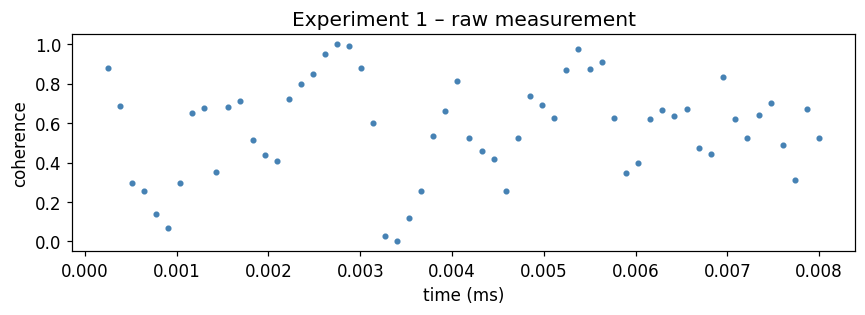

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  OPTION A  – Simulation (testing / validation)
# ─────────────────────────────────────────────────────────────────────────────
# coherence_data_1 = simulate_coherence_data(
#     spin_list  = config["ground_truth_spins"],
#     exp_params = exp1,
#     hf_df      = state["hf_df"],
#     seed       = config["random_seed"],
# )

# ─────────────────────────────────────────────────────────────────────────────
#  OPTION B  – Real experimental data
#  Uncomment and replace with your measured time and signal arrays:
# ─────────────────────────────────────────────────────────────────────────────
with open('exp_data/XY4_exp1_time.pkl', 'rb') as file:
    times_meas  = pkl.load(file)    # 1-D array (ms)
with open('exp_data/XY4_exp1_coherence.pkl', 'rb') as file:
    signal_meas = 0.5*(pkl.load(file))+0.5   # 1-D array (coherence, ~[-1,1])
times_meas, signal_meas = load_coherence_data_from_arrays(times_meas, signal_meas)
coherence_data_1 = [signal_meas]
exp1['timepoints'] = np.array([times_meas])

# Plot the raw data
plt.figure(figsize=(8, 3))
plt.plot(times_meas, signal_meas, ".", ms=6, color="steelblue")
plt.xlabel("time (ms)")
plt.ylabel("coherence")
plt.title("Experiment 1 – raw measurement")
plt.tight_layout()
plt.show()


### 3b · Run RJMCMC inference

In [20]:
# state = run_inference(
#     state            = state,
#     new_coherence_data = coherence_data_1,
#     new_exp_params   = exp1,
#     config           = config,
# )
state = load_state("spin_bath_XY4_exp1_posterior_1_pool.pkl")

State loaded ← spin_bath_XY4_exp1_posterior_1_pool.pkl  (iteration 1)


### 3c · Convergence diagnostics

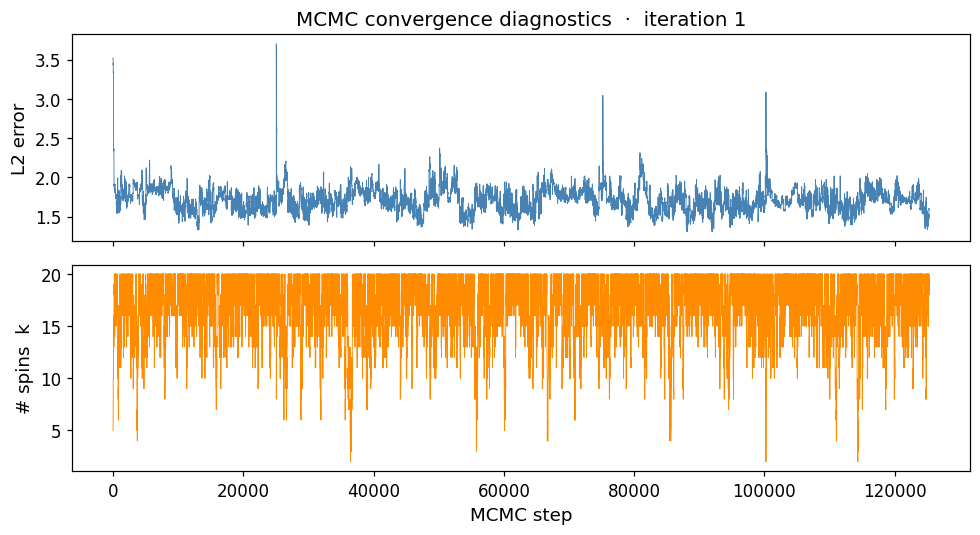

In [21]:
plot_convergence(state)


### 3d · Posterior distribution

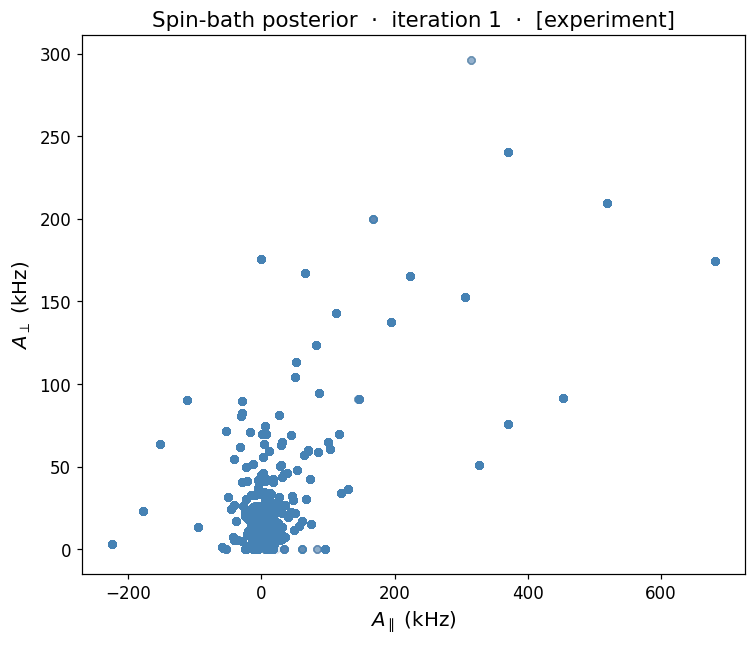

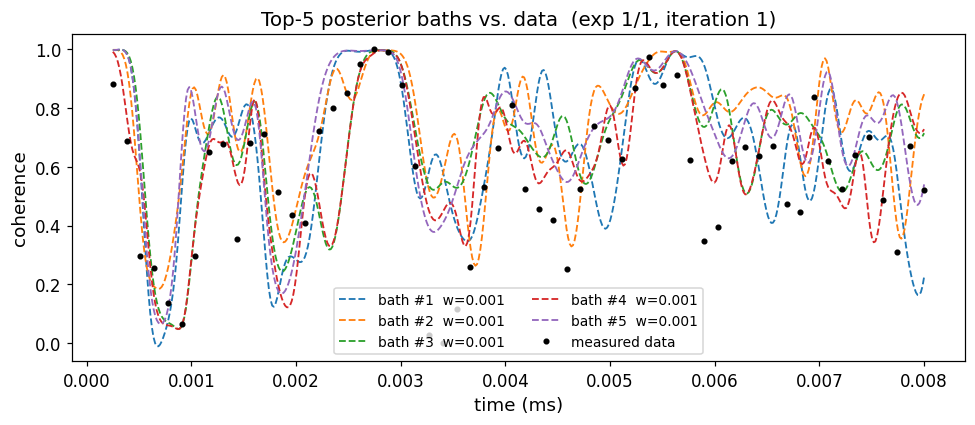


Top-5 spin-bath configurations  (iteration 1):
 rank  weight  count  num_spins                                                                                                                                                                                                                                                                                                           pairs_Apar_Aperp
    1  0.0007     46          4                                                                                                                                                                                                                                                            (-28.35, 89.86); (6.12, 41.09); (26.44, 80.95); (66.18, 166.95)
    2  0.0007     43         18                                         (-41.37, 54.53); (-9.51, 7.24); (-8.91, 4.89); (-7.80, 12.53); (-4.92, 7.80); (-3.71, 17.96); (-0.67, 7.05); (1.23, 5.25); (2.72, 12.06); (3.74, 5.47); (4.65, 7.44); (7.13, 5.38); (7.62,

In [22]:
plot_posterior(state, config)
plot_posterior_fits(state, config, exp_index=-1)
summary_1 = print_posterior_summary(state, config)


### 3e · Recommend the next experiment

Built 30 candidate experiments (6 pulse settings × 5 tmax values).

Scoring 30 candidate experiments …
  pruning_alpha = 0.5  |  M_eig = 200  |  Nt_dense = 300
  candidate 1/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 4/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 7/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 10/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 13/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 16/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 19/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 22/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 25/30 …
(17905, 150)
(17905, 150)
(17905, 150)
  candidate 28/30 …
(17905, 150)
(17905, 150)
(17905, 150)

✓ Best experiment selected:
  Pulses             : 4
  t_max              : 0.00100 ms
  Timepoints kept    : 150 / 300  (alpha = 0.5)
  EIG                : 7.2561 nats
  Cost (N_p × Σt)   : 0.3317 pulse·ms
  Utility (EIG/cost) : 21.874225

══════════

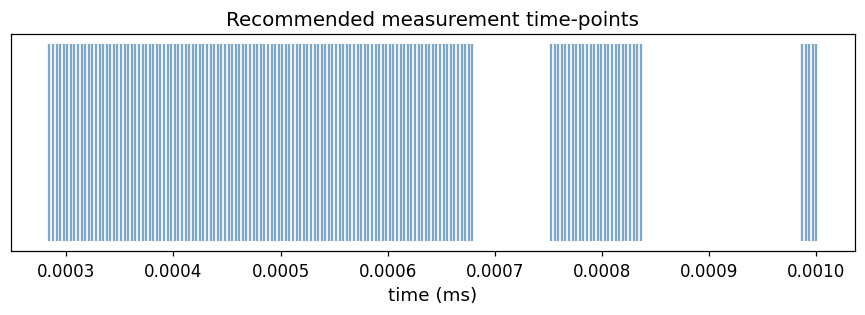

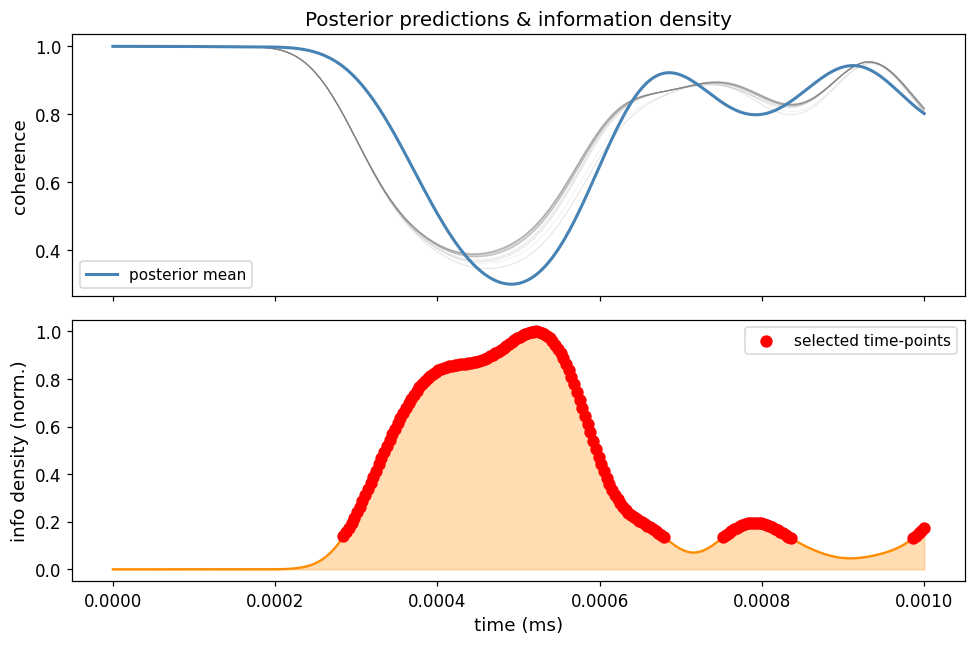

In [23]:
candidates = build_candidate_experiments(config)
recommendation_1 = suggest_next_experiment(state, config, candidates)
display_recommendation(recommendation_1)
plot_information_diagnostic(state, recommendation_1, config)


---
## 4 · Second Experiment

Perform the recommended experiment in the lab, then load the data below.

In [ ]:
# Retrieve optimised experiment parameters from the recommendation
exp2 = recommendation_1["optimized_exp"]

print("Second experiment parameters:")
print(f"  Pulses    : {exp2['num_pulses'][0]}")
print(f"  Mag field : {exp2['mag_field'][0]} G")
print(f"  Time range: {exp2['timepoints'][0][0]:.5f} – {exp2['timepoints'][0][-1]:.5f} ms")
print(f"  # points  : {len(exp2['timepoints'][0])}")


In [ ]:
# ── OPTION A  – Simulation ────────────────────────────────────────────────────
coherence_data_2 = simulate_coherence_data(
    spin_list  = config["ground_truth_spins"],
    exp_params = exp2,
    hf_df      = state["hf_df"],
    seed       = config["random_seed"],
)

# ── OPTION B  – Real data ─────────────────────────────────────────────────────
# times_meas  = np.load("exp2_times.npy")
# signal_meas = np.load("exp2_signal.npy")
# times_meas, signal_meas = load_coherence_data_from_arrays(times_meas, signal_meas)
# coherence_data_2 = [signal_meas]

plt.figure(figsize=(8, 3))
plt.plot(exp2["timepoints"][0], coherence_data_2[0], ".", ms=6, color="darkorange")
plt.xlabel("time (ms)")
plt.ylabel("coherence")
plt.title("Experiment 2 – raw measurement")
plt.tight_layout()
plt.show()


In [ ]:
state = run_inference(
    state              = state,
    new_coherence_data = coherence_data_2,
    new_exp_params     = exp2,
    config             = config,
)

plot_convergence(state)
plot_posterior(state, config)
plot_posterior_fits(state, config, exp_index=-1)
summary_2 = print_posterior_summary(state, config)


In [ ]:
recommendation_2 = suggest_next_experiment(state, config, candidates)
display_recommendation(recommendation_2)
plot_information_diagnostic(state, recommendation_2, config)


---
## 5 · Continuing Iterations

Copy-paste and re-run the pattern below for each new experiment:

```
exp_next = recommendation_N["optimized_exp"]

# --- load or simulate data ---
coherence_data_next = simulate_coherence_data(
    config["ground_truth_spins"], exp_next, state["hf_df"])
# (or load from file)

state = run_inference(state, coherence_data_next, exp_next, config)
plot_posterior(state, config)
summary = print_posterior_summary(state, config)
recommendation_next = suggest_next_experiment(state, config, candidates)
display_recommendation(recommendation_next)
```

---
## 6 · Save & Restore State

Use these cells to checkpoint and resume a long run without repeating MCMC.

In [ ]:
# Save the current pipeline state (posterior, samples, experiment history)
save_state(state, "spin_bath_run_state.pkl")


In [ ]:
# Restore a previously saved state (run this cell instead of the MCMC cells)
# state = load_state("spin_bath_run_state.pkl")
